# this notebook generates the arrayed TCR validation heatmaps

figures 2, 3, and s3


## imports and functions

In [ ]:
import pandas as pd 
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import re
from collections import defaultdict
from matplotlib.ticker import (
    MultipleLocator,
    AutoMinorLocator,
    LogLocator,
    FuncFormatter,
)
from scipy import interpolate
import matplotlib as mpl
import matplotlib.lines as lines
from matplotlib.lines import Line2D
from matplotlib import patches

import matplotlib.patches as patches
import matplotlib.colors as mcolors

In [3]:
def startfig(
    w=4, h=2, rows=1, columns=1, wrs=None, hrs=None, frameon=True, return_first_ax=True
):
    ratio = 0.393701  # 1 cm in inch
    myfigsize = (w * ratio, h * ratio)
    fig = plt.figure(figsize=(myfigsize))
    gs = mpl.gridspec.GridSpec(rows, columns, width_ratios=wrs, height_ratios=hrs)
    if return_first_ax == True:
        a = fig.add_subplot(gs[0, 0], frameon=frameon)
        return a, fig, gs
    else:
        return fig, gs

In [4]:
mylines = 0.75  # updated
mpl.rcParams["axes.linewidth"] = mylines  # default 1
mpl.rcParams["ytick.direction"] = "out"  # default 'in'
mpl.rcParams["xtick.direction"] = "out"  # default 'in'
mpl.rcParams["xtick.major.size"] = 3.5  # default 4
mpl.rcParams["ytick.major.size"] = 3.5  # default 4
mpl.rcParams["xtick.major.width"] = mylines  # default 0.5
mpl.rcParams["ytick.major.width"] = mylines  # default 0.5
mpl.rcParams["grid.linewidth"] = mylines / 1.5  # default 0.5
mpl.rcParams["grid.color"] = "0.8"  # default 'k'
mpl.rcParams["grid.linestyle"] = "solid"  # default ':'
mpl.rcParams["legend.frameon"] = False  # default True
mpl.rcParams["font.family"] = "Arial"  # added
mpl.rcParams["figure.dpi"] = 300
mpl.rc("savefig", dpi=300)
mpl.rcParams["pdf.fonttype"] = 42  # embed fonts as editable text in illustrator
mpl.rcParams["ps.fonttype"] = 42  # embed fonts as editable text in illustrator`

In [ ]:
arrayed_validation_overview_excel_path = 'Arrayed_testing_vdjdb_overview.xlsx'
output_path = ''

In [ ]:
import json

with open('name_color_dict_rebuttal.json') as f:
    color_dict = json.load(f)

color_dict.update({'poly': 'lightgrey'})

color_dict

{'other': 'lightgrey',
 'GILGFVFTL': 'plum',
 'YLQPRTFLL': 'cornflowerblue',
 'TTDPSFLGRY': 'forestgreen',
 'NLVPMVATV': 'darkorange',
 'SPRWYFYYL': 'mediumorchid',
 'CINGVCWTV': 'darkturquoise',
 'LLWNGPMAV': 'gold',
 'GLCTLVAML': 'indianred',
 'LTDEMIAQY': 'darkviolet',
 'ATDALMTGF': 'teal',
 'hla-b0702': 'magenta',
 'control': 'darkgrey',
 'aspecific control': 'TBD',
 'not_this_epi': 'brown',
 'sig_in_tetra': 'lime',
 'selected_sig_in_tetra': 'purple',
 'ylq_wrong_side_preprint_version': 'darkgreen',
 'negative': 'darkgray',
 'ambiguous': 'black',
 'poly': 'lightgrey'}

In [7]:
# abbreviation dict

abbreviation_dict = dict({'YLQ' : 'YLQPRTFLL',
                          'GLC': 'GLCTLVAML',
                          'GILG': 'GILGFVFTL',
                          'NLV': 'NLVPMVATV',
                          'LLW': 'LLWNGPMAV',
                          'TTD': 'TTDPSFLGRY',
                          'SPR': 'SPRWYFYYL',
                          'CIN': 'CINGVCWTV',
                          'ATD': 'ATDALMTGF',
                          'LTD': 'LTDEMIAQY'})

In [8]:
arrayed_validation_overview_df = pd.read_excel(arrayed_validation_overview_excel_path, sheet_name='data_sheet_functional')

In [ ]:
arrayed_validation_overview_df = arrayed_validation_overview_df.drop(columns=['Unnamed: 0', 
                                             'Transduction batch',
                                             'CD69_negative_control_A', 
                                             'CD69_negative_control_B', 
                                             'CD69_condition_1_A', 
                                             'CD69_condition_1_B', 
                                             'CD69_condition_2_A', 
                                             'CD69_condition_2_B',
                                             'Comment',
                                             'Experiment'])



In [10]:
def prep_functional_df_for_heatmap(df: pd.DataFrame):

    # construct color list for annotation
    color_list_annot = [color_dict.get(epi, 'black') for epi in df.loc[:, 'ID'].apply(lambda x: x.split('_')[-1]).to_list()]

    # construct color list screen result
    color_list_screen = [color_dict.get(full_epi, 'black') for full_epi in [abbreviation_dict.get(epi, 'black') for epi in df.loc[:, 'condition_1'].to_list()]]

    df.loc[:, 'plate_well_epi'] =  df.loc[:, 'plate_well'] + '_' + df.loc[:, 'ID'].apply(lambda x: x.split('_')[4][0:3])

    subset_df = df.loc[:, ['plate_well_epi', 'negative_control', 
                            'CD69_negative_control_mean', 'condition_1', 
                            'CD69_condition_1_mean', 'condition_2',
                            'CD69_condition_2_mean']]
    
    for value in subset_df.loc[:, 'negative_control'].unique():
        if pd.isna(value):  
            continue
        array = np.where(subset_df.loc[:, 'negative_control'] == value, subset_df.loc[:, 'CD69_negative_control_mean'], np.nan)
        subset_df.loc[:, value] = array


    for value in subset_df.loc[:, 'condition_1'].unique():
        if pd.isna(value):  
            continue
        array = np.where(subset_df.loc[:, 'condition_1'] == value, subset_df.loc[:, 'CD69_condition_1_mean'], np.nan)
        subset_df.loc[:, value] = array

    for value in subset_df.loc[:, 'condition_2'].unique():
        if pd.isna(value):  
            continue

        array = np.where(subset_df.loc[:, 'condition_2'] == value, subset_df.loc[:, 'CD69_condition_2_mean'], np.nan)
        
        if value in subset_df.columns: 
            
            existing_array = subset_df.loc[:, value].to_numpy()
            
            merged_array = np.where(np.isnan(existing_array), array, existing_array)
            subset_df[value] = merged_array

        else:
            subset_df.loc[:, value] = array
        
    # remove these columns 
    subset_df = subset_df.drop(columns=['negative_control', 'CD69_negative_control_mean', 
                                  'condition_1', 'condition_2', 
                                  'CD69_condition_1_mean', 'CD69_condition_2_mean'])
    
    subset_df = subset_df.set_index('plate_well_epi', drop=True).transpose()

    # get the ytick colors as a list

    color_list_yticks = [color_dict.get(full_epi, 'black') for full_epi in [abbreviation_dict.get(epi, 'black') for epi in subset_df.index.tolist()]]


    return subset_df, color_list_annot, color_list_screen, color_list_yticks
        

## polyreactive TCRs heatmap

In [ ]:
poly_subset_arrayed_df = arrayed_validation_overview_df[arrayed_validation_overview_df.loc[:, 'category'] == 'Poly']

poly_subset_arrayed_df, poly_ann_color_list, poly_screen_color_list, color_list_poly_yticks = prep_functional_df_for_heatmap(poly_subset_arrayed_df)

poly_subset_arrayed_df = poly_subset_arrayed_df[::-1]



In [ ]:
rows_to_insert = ['untransduced HLA-A01', 'GILG', 'GLC', 'NLV', 'YLQ', 'CIN']

# Insert rows filled with NaN
for r in rows_to_insert:
    if r not in poly_subset_arrayed_df.index:
        poly_subset_arrayed_df.loc[r] = np.nan

# Optional: reorder the rows if needed
desired_order = ['untransduced HLA-A02', 'GILG', 'GLC', 'NLV', 'YLQ', 'CIN']
poly_subset_arrayed_df = poly_subset_arrayed_df.reindex(desired_order)



In [26]:
poly_color_list_yticks = ['black', 'plum', 'indianred', 'darkorange', 'cornflowerblue', 'darkturquoise']

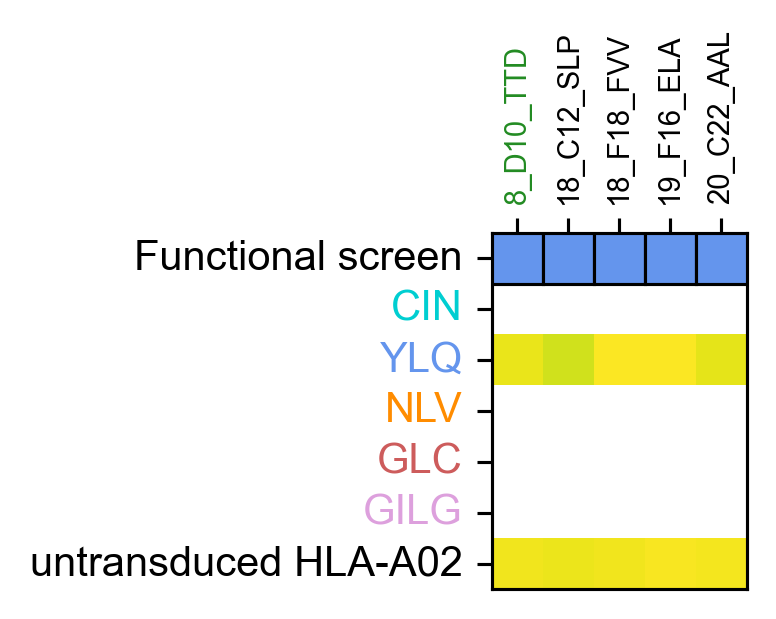

In [34]:
# now make grid with wrong_ann and poly_reactive

fig_width = 13
fig_height = 5.5
fontsize = 7

ax, fig, gs = startfig(fig_width, fig_height)

ax = sns.heatmap(poly_subset_arrayed_df, 
                 square=True, 
                 cmap='viridis',
                 vmin=0,
                 vmax=1)


# ax.set_xlabel('TCR ID with VDJdb annotation', fontsize = fontsize)
ax.set_xlabel('')
ax.set_xticks(np.arange(len(poly_subset_arrayed_df.columns))+0.5)
ax.set_xticklabels(poly_subset_arrayed_df.columns, rotation = 90, ha='center', fontsize = fontsize)
# ax2.set_yticklabels(ax.get_yticklabels(), fontsize=fontsize)
ax.xaxis.set_ticks_position('top') 
ax.xaxis.set_label_position('top') 

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')  # color of outer line
    spine.set_linewidth(0.75)    # thickness of outer line

colorbar = ax.collections[0].colorbar
# colorbar.set_ticklabels([0, 1])
colorbar.remove()

# xtick colors
xticks = ax.get_xticklabels()

for tick, color in zip(xticks, poly_ann_color_list):
    tick.set_color(color)

# top annotation as extra row in data coordinates
n_cols = len(poly_subset_arrayed_df.columns)
n_rows = len(poly_subset_arrayed_df.index)
top_y = n_rows  # one unit below first row

# extend y-limits slightly to make room
ax.set_ylim(0, n_rows + 1)

# yticks 
yticks = list(ax.get_yticks()) + [top_y + 0.5]
yticklabels = ax.get_yticklabels()
ax.set_yticks(yticks)        # removes the ticks
ax.set_yticklabels(yticklabels + ['Functional screen'])   # removes the labels


for label, color in zip(ax.get_yticklabels(),
                        poly_color_list_yticks + ['black']):
    label.set_color(color)

# draw squares that match heatmap exactly
for i, color in enumerate(poly_screen_color_list):
    rect = patches.Rectangle(
        (i, top_y), 1, 1,  # width=1, height=1 matches squares
        facecolor=color,
        edgecolor='black',
        linewidth=0.75,
        zorder = 10)
    ax.add_patch(rect)

fig.tight_layout()
# plt.savefig(os.path.join(output_path, 'heatmap_wrong_ann_tcr_poly_reactive_version_2.pdf'))

## Wrong annotation TCRs heatmap

In [ ]:
wrong_ann_subset_df = arrayed_validation_overview_df[arrayed_validation_overview_df.loc[: , 'category'].isin(['Clustering-based GILG', 
                                                                                                              'Clustering-based GLC',
                                                                                                              'GLC both tetramer & functional',
                                                                                                              'Clustering-based NLV'
                                                                                                              ])]

wrong_ann_subset_df,_,_, color_ytick_list = prep_functional_df_for_heatmap(wrong_ann_subset_df)

In [13]:
wrong_ann_subset_GILG_df = wrong_ann_subset_df.loc[:, ['10_A18_NLV', '14_D24_LLW', '18_B7_MLF','18_E17_GLT']]
wrong_ann_subset_GLC_df = wrong_ann_subset_df.loc[:, ['13_E17_CIN', '13_F22_CIN', '13_G11_CIN', '8_G15_TTD']]
wrong_ann_subset_NLV_df = wrong_ann_subset_df.loc[:, ['1_H12_GIL', '1_H20_GIL', '2_H20_GIL']]

In [35]:
color_dict

{'other': 'lightgrey',
 'GILGFVFTL': 'plum',
 'YLQPRTFLL': 'cornflowerblue',
 'TTDPSFLGRY': 'forestgreen',
 'NLVPMVATV': 'darkorange',
 'SPRWYFYYL': 'mediumorchid',
 'CINGVCWTV': 'darkturquoise',
 'LLWNGPMAV': 'gold',
 'GLCTLVAML': 'indianred',
 'LTDEMIAQY': 'darkviolet',
 'ATDALMTGF': 'teal',
 'hla-b0702': 'magenta',
 'control': 'darkgrey',
 'aspecific control': 'TBD',
 'not_this_epi': 'brown',
 'sig_in_tetra': 'lime',
 'selected_sig_in_tetra': 'purple',
 'ylq_wrong_side_preprint_version': 'darkgreen',
 'negative': 'darkgray',
 'ambiguous': 'black',
 'poly': 'lightgrey'}

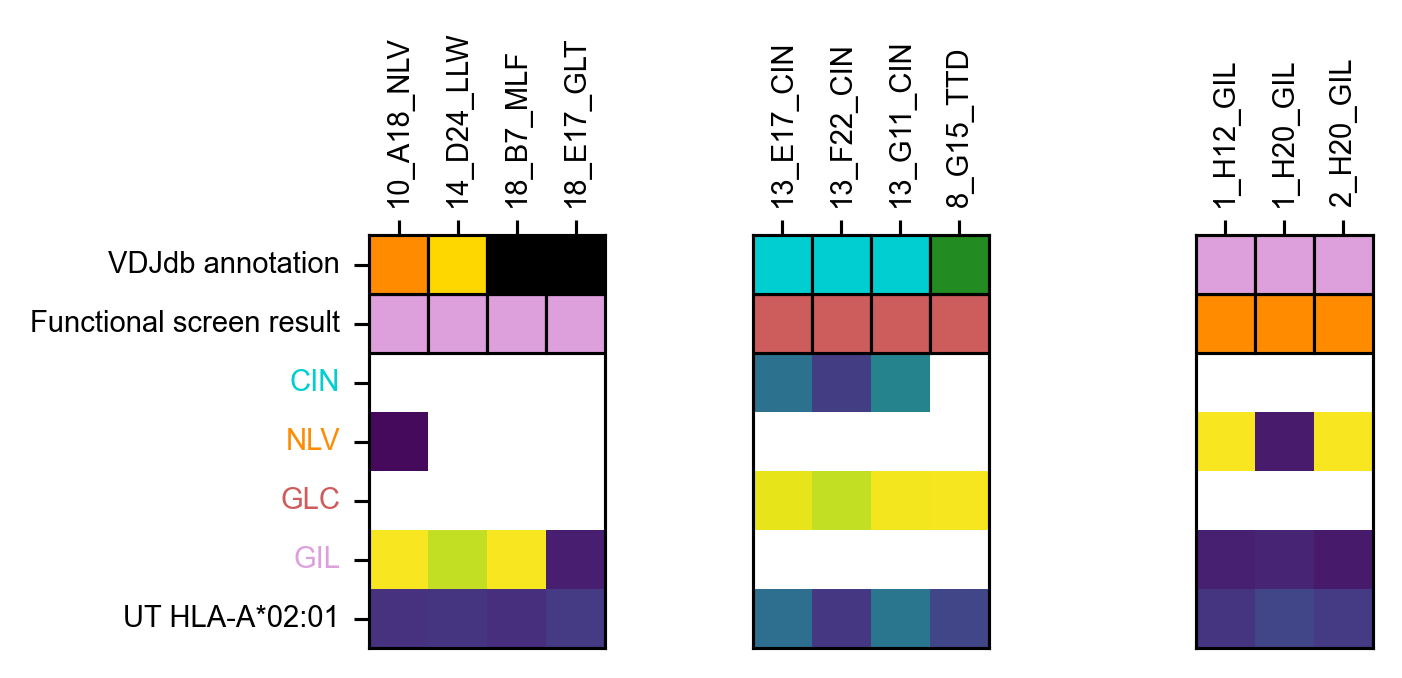

In [56]:
# now make grid with wrong_ann and poly_reactive
fontsize = 7
linewidth = 0.75

fig_width = 13
fig_height = 6

ax1, fig, gs = startfig(fig_width, fig_height, rows=1, columns=3)

ax1 = sns.heatmap(wrong_ann_subset_GILG_df, 
                 square=True, 
                 cmap='viridis',
                 vmin=0,
                 vmax=1, # set to 99th percentile (normalize?)
                 cbar_kws = {'shrink': (fig_height/(2.5*fig_height)), 
                             'aspect': 20,
                             'ticks': [0, 1]})

ax1.set_xlabel('')
ax1.set_xticks(np.arange(len(wrong_ann_subset_GILG_df.columns))+0.5)
ax1.set_xticklabels(wrong_ann_subset_GILG_df.columns, rotation = 90, ha='center', fontsize = fontsize)
ax1.xaxis.set_ticks_position('top') 
ax1.xaxis.set_label_position('top') 

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('black')  # color of outer line
    spine.set_linewidth(0.75)    # thickness of outer line

# # # set ticks colorbar
colorbar = ax1.collections[0].colorbar
colorbar.remove()

# xtick colors
xticks = ax1.get_xticklabels()
ax1.set_xticklabels(xticks, color='black')

# --- bottom annotation as extra row in data coordinates ---
n_cols = len(wrong_ann_subset_GILG_df.columns)
n_rows = len(wrong_ann_subset_GILG_df.index)
top_y = n_rows  # one unit below first row

# extend y-limits slightly to make room
ax1.set_ylim(0, n_rows + 2)

for i, color in enumerate(['plum','plum','plum','plum']):
    rect = patches.Rectangle(
        (i, top_y), 1, 1,  # width=1, height=1 matches squares
        facecolor=color,
        edgecolor='black',
        linewidth=0.75,
        zorder = 10)
    ax1.add_patch(rect)
    
for i, color in enumerate(['darkorange','gold','black','black']):
    rect = patches.Rectangle(
        (i, top_y+1), 1, 1,  # width=1, height=1 matches squares
        facecolor=color,
        edgecolor='black',
        linewidth=0.75,
        zorder = 10)
    ax1.add_patch(rect)
    

# ytick colors
yticks = ax1.get_yticklabels()

for tick, color in zip(yticks, color_ytick_list):
    tick.set_color(color)


yticks = list(ax1.get_yticks()) + [top_y + 0.5] + [top_y +1.5] 
yticklabels = ['UT HLA-A*02:01', 'GIL', 'GLC', 'NLV', 'CIN', "Functional screen result", 'VDJdb annotation']

ax1.set_yticks(yticks)
ax1.set_yticklabels(yticklabels, fontsize=fontsize)


ax2 = fig.add_subplot(gs[1])

ax2 = sns.heatmap(wrong_ann_subset_GLC_df, 
                 square=True, 
                 cmap='viridis',
                 vmin=0,
                 vmax=1)

ax2.set_xlabel('')
ax2.set_xticks(np.arange(len(wrong_ann_subset_GLC_df.columns))+0.5)
ax2.set_xticklabels(wrong_ann_subset_GLC_df.columns, rotation = 90, ha='center', fontsize = fontsize)
ax2.xaxis.set_ticks_position('top') 
ax2.xaxis.set_label_position('top') 

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('black')  # color of outer line
    spine.set_linewidth(0.75)    # thickness of outer line

colorbar = ax2.collections[0].colorbar
colorbar.remove()

# # # xtick colors
# xticks = ax2.get_xticklabels()
# ax2.set_xticklabels(xticks, color='black')


# # --- top annotation as extra row in data coordinates ---
n_cols = len(wrong_ann_subset_GLC_df.columns)
n_rows = len(wrong_ann_subset_GLC_df.index)
top_y = n_rows  # one unit below first row

# # extend y-limits slightly to make room
ax2.set_ylim(0, n_rows + 2)

for i, color in enumerate(['indianred','indianred','indianred','indianred']):
    rect = patches.Rectangle(
        (i, top_y), 1, 1,  # width=1, height=1 matches squares
        facecolor=color,
        edgecolor='black',
        linewidth=0.75,
        zorder = 10)
    ax2.add_patch(rect)
    
for i, color in enumerate(['darkturquoise','darkturquoise','darkturquoise','forestgreen']):
    rect = patches.Rectangle(
        (i, top_y+1), 1, 1,  # width=1, height=1 matches squares
        facecolor=color,
        edgecolor='black',
        linewidth=0.75,
        zorder = 10)
    ax2.add_patch(rect)


ax2.set_yticks([])        # removes the ticks
ax2.set_yticklabels([])   # removes the labels

ax3 = fig.add_subplot(gs[2])

ax3 = sns.heatmap(wrong_ann_subset_NLV_df, 
                 square=True, 
                 cmap='viridis',
                 vmin=0,
                 vmax=1)

ax3.set_xlabel('')
ax3.set_xticks(np.arange(len(wrong_ann_subset_NLV_df.columns))+0.5)
ax3.set_xticklabels(wrong_ann_subset_NLV_df.columns, rotation = 90, ha='center', fontsize = fontsize)
ax3.xaxis.set_ticks_position('top') 
ax3.xaxis.set_label_position('top') 

for spine in ax3.spines.values():
    spine.set_visible(True)
    spine.set_color('black')  # color of outer line
    spine.set_linewidth(0.75)    # thickness of outer line

colorbar = ax3.collections[0].colorbar
colorbar.remove()

# # # xtick colors
# xticks = ax2.get_xticklabels()
# ax2.set_xticklabels(xticks, color='black')


# # --- top annotation as extra row in data coordinates ---
n_cols = len(wrong_ann_subset_NLV_df.columns)
n_rows = len(wrong_ann_subset_NLV_df.index)
top_y = n_rows  # one unit below first row

# # extend y-limits slightly to make room
ax3.set_ylim(0, n_rows + 2)

for i, color in enumerate(['darkorange','darkorange','darkorange']):
    rect = patches.Rectangle(
        (i, top_y), 1, 1,  # width=1, height=1 matches squares
        facecolor=color,
        edgecolor='black',
        linewidth=0.75,
        zorder = 10)
    ax3.add_patch(rect)
    
for i, color in enumerate(['plum','plum','plum']):
    rect = patches.Rectangle(
        (i, top_y+1), 1, 1,  # width=1, height=1 matches squares
        facecolor=color,
        edgecolor='black',
        linewidth=0.75,
        zorder = 10)
    ax3.add_patch(rect)


ax3.set_yticks([])        # removes the ticks
ax3.set_yticklabels([])   # removes the labels

fig.tight_layout()
fig.savefig(os.path.join(output_path, 'heatmap_wrong_ann_split.pdf'))

## tetramer vs functional heatmap

In [36]:
tetramer_binding_overview_df = pd.read_excel(arrayed_validation_overview_excel_path, sheet_name='data_sheet_tetramer')

In [35]:
def prep_tetramer_df_for_heatmap(df: pd.DataFrame,
                                 normalize_TCR: bool):
    
    if not isinstance(normalize_TCR, bool):
        raise ValueError('You must provide boolean value for normalize_TCR')
    
    if normalize_TCR:
        subset_df = df.loc[:, ['plate_well', 
                        'unrelated_HLA_A02_tetramer', 
                        'YLQ_tetramer_binding_mean', 
                        'GLC_tetramer_binding_mean',
                        'TCR_TE_ratio']]
        
        for condition in ['unrelated_HLA_A02_tetramer', 'YLQ_tetramer_binding_mean', 'GLC_tetramer_binding_mean']:
            subset_df.loc[:, condition] = subset_df.loc[:, condition] / subset_df.loc[:, 'TCR_TE_ratio']

        subset_df = subset_df.drop(columns= ['TCR_TE_ratio'])
        
        
    else:
        subset_df = df.loc[:, ['plate_well', 
                        'unrelated_HLA_A02_tetramer', 
                        'YLQ_tetramer_binding_mean', 
                        'GLC_tetramer_binding_mean']]
        

    subset_df = subset_df.set_index('plate_well', drop=True).transpose()
        
    return subset_df

In [39]:
tetramer_binding_ylq_df = tetramer_binding_overview_df[tetramer_binding_overview_df.loc[:, 'category'].isin(['Low Padj Tetramer YLQ, not significant functional',
                                                                                                             'YLQ TCR <-1 LFC',
                                                                                                             'Low Padj functional, high Padj tetramer YLQ'])]

tetramer_binding_ylq_df = prep_tetramer_df_for_heatmap(tetramer_binding_ylq_df, normalize_TCR=True)

tetramer_binding_ylq_df = tetramer_binding_ylq_df.iloc[::-1]

In [37]:
# now link this plot to the functional plot

functional_ylq_df = arrayed_validation_overview_df[arrayed_validation_overview_df.loc[:, 'category'].isin(['Low Padj Tetramer YLQ, not significant functional',
                                                                                                             'YLQ TCR <-1 LFC',
                                                                                                             'Low Padj functional, high Padj tetramer YLQ'])]

functional_ylq_df, ylq_color_list_annot, ylq_color_list_screen, ylq_yticks_color_list  = prep_functional_df_for_heatmap(functional_ylq_df)

/var/folders/9r/cz_klq517z77zm7ly3p7k4_171lx__/T/ipykernel_24507/27274150.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'plate_well_epi'] =  df.loc[:, 'plate_well'] + '_' + df.loc[:, 'ID'].apply(lambda x: x.split('_')[4][0:3])


In [38]:
functional_ylq_df.loc['GLC', :] = np.nan

functional_ylq_df

plate_well_epi,6_F11_YLQ,4_H18_YLQ,5_G3_YLQ,4_G17_YLQ,6_G14_YLQ,6_A24_YLQ,6_G11_YLQ,4_H17_YLQ
untransduced HLA-A02,0.4890,0.1740,0.287,0.174,0.148,0.331,0.2850,0.228
YLQ,0.9875,0.9915,0.986,0.089,0.279,0.239,0.9065,0.973
GLC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


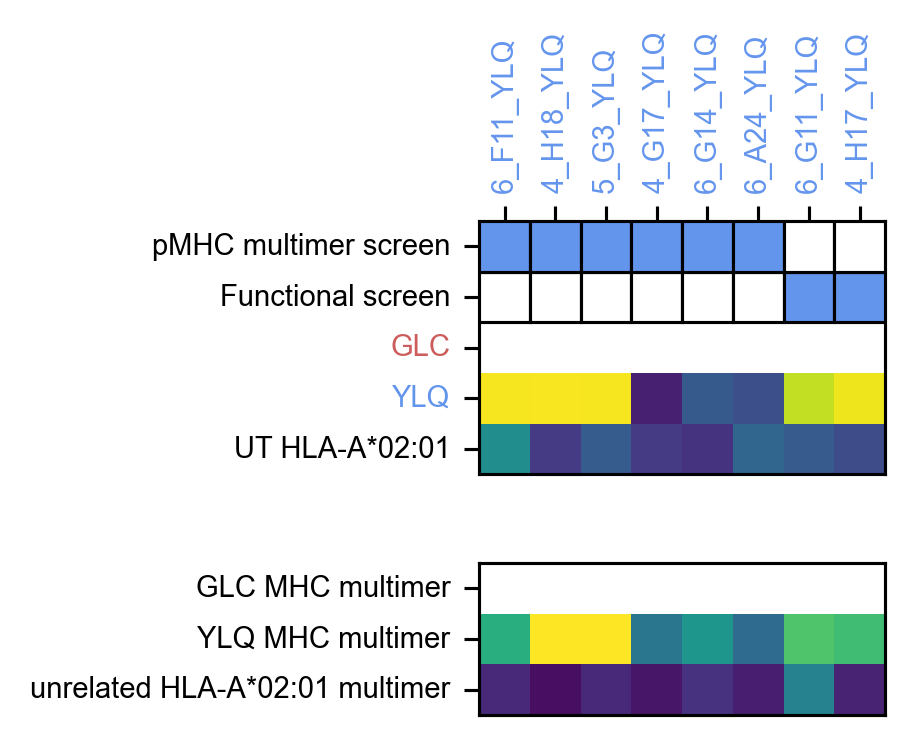

In [40]:
fig_width = 8
fig_height = 7
fontsize = 7
linewidth = 0.75

ax1, fig, gs = startfig(fig_width, fig_height, rows=2, columns=1)

ax1 = sns.heatmap(functional_ylq_df, 
                 square=True, 
                 cmap='viridis',
                 vmin=0,
                 vmax=1, # set to 99th percentile (normalize?)
                cbar=False)

# ax1.set_xlabel('TCR ID with VDJdb annotation', fontsize = fontsize)
ax1.set_xlabel(None)
ax1.set_xticks(np.arange(len(functional_ylq_df.columns))+0.5)
ax1.set_xticklabels(functional_ylq_df.columns, rotation = 90, ha='center', fontsize = fontsize)
ax1.set_yticklabels(['UT HLA-A*02:01', 'YLQ', 'GLC'], fontsize=fontsize)
ax1.xaxis.set_ticks_position('top') 
ax1.xaxis.set_label_position('top') 

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('black')  # color of outer line
    spine.set_linewidth(linewidth)    # thickness of outer line

# xtick colors
xticks = ax1.get_xticklabels()

for tick, color in zip(xticks, ylq_color_list_annot):
    tick.set_color(color)


# ytick colors
yticks = ax1.get_yticklabels()

for tick, color in zip(yticks, ['black', 'cornflowerblue', 'indianred']):
    tick.set_color(color)

# --- bottom annotation as extra row in data coordinates ---
n_cols = len(functional_ylq_df.columns)
n_rows = len(functional_ylq_df.index)
top_y = n_rows  # one unit below first row

# extend y-limits slightly to make room
ax1.set_ylim(0, n_rows + 2)


# draw squares that match heatmap exactly
for i, color in enumerate(['white', 'white', 'white', 'white',
                           'white', 'white', 'cornflowerblue', 'cornflowerblue']): # make a dict 
    rect = patches.Rectangle(
        (i, top_y), 1, 1,  # width=1, height=1 matches squares
        facecolor=color,
        edgecolor='black',
        linewidth=linewidth,
        zorder = 10)
    ax1.add_patch(rect)


for i, color in enumerate([
    'cornflowerblue','cornflowerblue','cornflowerblue','cornflowerblue',
    'cornflowerblue','cornflowerblue','white','white']):

    # Convert color to RGBA
    rgba = list(mcolors.to_rgba(color))
    rgba[3] = 1  # facecolor alpha

    rect = patches.Rectangle(
        (i, top_y+1), 1, 1,
        facecolor=rgba,        # semi-transparent
        edgecolor='black',     # fully opaque
        linewidth=linewidth,
        zorder=10
    )
    ax1.add_patch(rect)
    
yticks = list(ax1.get_yticks())
yticklabels = [t.get_text() for t in ax1.get_yticklabels()]

yticks.extend([n_rows + 0.5, n_rows + 1.5])
yticklabels.extend(["Functional screen",
                   "pMHC multimer screen"])

ax1.set_yticks(yticks)
ax1.set_yticklabels(yticklabels)

ax2 = fig.add_subplot(gs[1])

ax2 = sns.heatmap(tetramer_binding_ylq_df, 
                 square=True, 
                 cmap='viridis',
                 vmin=0, 
                 vmax= 1, ## 99th percentile
                 cbar=False)  

ax2.set_xlabel(None)
ax2.set_xticks(np.arange(len(tetramer_binding_ylq_df.columns))+0.5)
ax2.set_xticklabels(tetramer_binding_ylq_df.columns, rotation = 90, ha='center', fontsize = fontsize)
ax2.set_yticklabels(['GLC MHC multimer','YLQ MHC multimer','unrelated HLA-A*02:01 multimer'], fontsize=fontsize)
ax2.xaxis.set_ticks_position('top') 
ax2.xaxis.set_label_position('top')

ax2.tick_params(axis='x',
                which='both',
                top=False,   # removes bottom ticks if any
                labeltop=False)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('black')  # color of outer line
    spine.set_linewidth(0.75)    # thickness of outer line


plt.tight_layout()
# plt.savefig(os.path.join(output_path, 'functional_vs_tetramer_ylq_only.pdf'))
plt.show()

In [42]:
tetramer_binding_glc_df = tetramer_binding_overview_df[tetramer_binding_overview_df.loc[:, 'category'].isin(['Low Padj Tetramer GLC, not significant functional',
                                                                                                             'Low Padj functional, high Padj tetramer GLC'])]

tetramer_binding_glc_df  = prep_tetramer_df_for_heatmap(tetramer_binding_glc_df, normalize_TCR=True)

tetramer_binding_glc_df = tetramer_binding_glc_df.iloc[::-1]

In [43]:
functional_glc_df = arrayed_validation_overview_df[arrayed_validation_overview_df.loc[:, 'category'].isin(['Low Padj Tetramer GLC, not significant functional',
                                                                                                             'Low Padj functional, high Padj tetramer GLC'])]


functional_glc_df, glc_color_list_annot, glc_color_list_screen, glc_yticks_color_list  = prep_functional_df_for_heatmap(functional_glc_df)


functional_glc_df.loc['YLQ', :] = np.nan

functional_glc_df = functional_glc_df.loc[['untransduced HLA-A02', 'YLQ', 'GLC']]

/var/folders/9r/cz_klq517z77zm7ly3p7k4_171lx__/T/ipykernel_24507/27274150.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'plate_well_epi'] =  df.loc[:, 'plate_well'] + '_' + df.loc[:, 'ID'].apply(lambda x: x.split('_')[4][0:3])


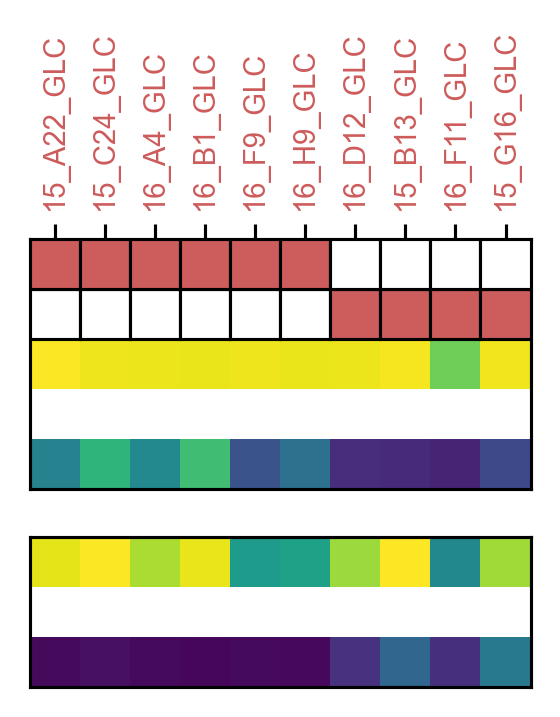

In [44]:
fig_width = 5
fig_height = 7
fontsize = 7
linewidth = 0.75

ax1, fig, gs = startfig(fig_width, fig_height, rows=2, columns=1)

ax1 = sns.heatmap(functional_glc_df, 
                 square=True, 
                 cmap='viridis',
                 vmin=0,
                 vmax=1, # set to 99th percentile (normalize?)
                cbar=False)

# ax1.set_xlabel('TCR ID with VDJdb annotation', fontsize = fontsize)
ax1.set_xlabel(None)
ax1.set_xticks(np.arange(len(functional_glc_df.columns))+0.5)
ax1.set_xticklabels(functional_glc_df.columns, rotation = 90, ha='center', fontsize = fontsize)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=fontsize)
ax1.xaxis.set_ticks_position('top') 
ax1.xaxis.set_label_position('top') 

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('black')  # color of outer line
    spine.set_linewidth(linewidth)    # thickness of outer line

# xtick colors
xticks = ax1.get_xticklabels()

for tick, color in zip(xticks, glc_color_list_annot):
    tick.set_color(color)


# ytick colors
yticks = ax1.get_yticklabels()

for tick, color in zip(yticks, ['black', 'cornflowerblue', 'indianred']):
    tick.set_color(color)

# --- bottom annotation as extra row in data coordinates ---
n_cols = len(functional_glc_df.columns)
n_rows = len(functional_glc_df.index)
top_y = n_rows  # one unit below first row

# extend y-limits slightly to make room
ax1.set_ylim(0, n_rows + 2)


# draw squares that match heatmap exactly
for i, color in enumerate(['white', 'white', 'white', 'white',
                           'white', 'white', 'indianred', 'indianred', 'indianred', 'indianred']): # make a dict 
    rect = patches.Rectangle(
        (i, top_y), 1, 1,  # width=1, height=1 matches squares
        facecolor=color,
        edgecolor='black',
        linewidth=linewidth,
        zorder = 10)
    ax1.add_patch(rect)



for i, color in enumerate([
    'indianred','indianred','indianred','indianred',
    'indianred','indianred','white','white','white','white']):

    # Convert named color to RGBA
    rgba = list(mcolors.to_rgba(color))
    rgba[3] = 1  # set alpha for facecolor

    rect = patches.Rectangle(
        (i, top_y+1), 1, 1,
        facecolor=rgba,               # RGBA with alpha 0.5
        edgecolor='black',            # Solid color (alpha=1)
        linewidth=linewidth,
        zorder=10
    )
    ax1.add_patch(rect)

# yticks = list(ax1.get_yticks())
# yticklabels = [t.get_text() for t in ax1.get_yticklabels()]

# yticks.extend([n_rows + 0.5, n_rows + 1.5])
# yticklabels.extend(["Pooled functional screen result",
#                    "Pooled tetramer screen result"])

ax1.set_yticks([])
ax1.set_yticklabels([])

# # Add an extra tick and tick label at position y = -1
# for i, label in enumerate(["Pooled functional screen result",
#                            "Pooled tetramer screen result"]):
#     y_pos = bottom_y - i + 0.5
#     yticks.append(y_pos)
#     yticklabels.append(label)

ax2 = fig.add_subplot(gs[1])

ax2 = sns.heatmap(tetramer_binding_glc_df, 
                 square=True, 
                 cmap='viridis',
                 vmin=0, 
                 vmax= 1, ## 99th percentile
                 cbar=False)  

ax2.set_xlabel(None)
ax2.set_xticks(np.arange(len(tetramer_binding_glc_df.columns))+0.5)
ax2.set_xticklabels(tetramer_binding_glc_df.columns, rotation = 90, ha='center', fontsize = fontsize)
ax2.xaxis.set_ticks_position('top') 
ax2.xaxis.set_label_position('top')
ax2.tick_params(axis='x',
                which='both',
                top=False,   # removes bottom ticks if any
                labeltop=False)


# ax2.set_yticklabels(['unrelated HLA-A02*01 tetramer', 'YLQ-binding tetramer', 'GLC-binding tetramer'], fontsize=fontsize)
ax2.set_yticks([])
ax2.set_yticklabels([])

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_color('black')  # color of outer line
    spine.set_linewidth(0.75)    # thickness of outer line


plt.tight_layout()
# plt.savefig(os.path.join(output_path, 'tetramer_vs_functional_glc_only_without_yaxis.pdf'))
plt.show()